# Task
Reduce the dimensionality of the Wholesale Customers Dataset using PCA and t-SNE, visualize the results colored by the 'Channel' feature, compare the performance and insights from both methods, and generate a README.md file summarizing the findings.

## Pendahuluan dan Import Library

### Subtask:
Menulis bagian pendahuluan notebook yang menjelaskan latar belakang masalah dan alasan penggunaan reduksi dimensi. Kemudian, mengimpor semua library yang diperlukan seperti pandas, numpy, matplotlib, seaborn, serta StandardScaler, PCA, dan TSNE dari scikit-learn.


### Pendahuluan

Dataset 'Wholesale Customers' berisi data transaksi pelanggan grosir. Dataset ini mencakup berbagai metrik seperti jumlah pengeluaran tahunan untuk berbagai kategori produk (misalnya, susu, bahan habis pakai, bahan segar, dll.). Tujuan utama dari analisis ini adalah untuk memahami pola pembelian pelanggan grosir dan mengidentifikasi segmen pelanggan yang berbeda berdasarkan perilaku pembelian mereka. Namun, dataset ini memiliki dimensi yang relatif tinggi, yang dapat mempersulit visualisasi dan analisis langsung.

Untuk mengatasi tantangan ini, kita akan menggunakan teknik reduksi dimensi. Reduksi dimensi membantu mengurangi jumlah variabel yang dipertimbangkan, sambil mempertahankan informasi penting sebanyak mungkin. Dalam notebook ini, kita akan fokus pada dua teknik reduksi dimensi utama:

1.  **Principal Component Analysis (PCA)**: Sebuah teknik linier yang mengubah data ke sistem koordinat baru sehingga varians terbesar ada pada dimensi pertama.
2.  **t-Distributed Stochastic Neighbor Embedding (t-SNE)**: Sebuah teknik non-linier yang sangat efektif untuk visualisasi data dimensi tinggi ke ruang berdimensi rendah (biasanya 2 atau 3 dimensi), dengan fokus pada pelestarian kedekatan titik data.

Dengan menerapkan PCA dan t-SNE, kita berharap dapat memvisualisasikan struktur tersembunyi dalam data, mengidentifikasi kelompok pelanggan yang berbeda, dan mendapatkan wawasan yang lebih baik tentang pola pembelian mereka, yang pada akhirnya dapat membantu dalam strategi pemasaran dan pengelolaan inventaris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Libraries imported successfully.")

Libraries imported successfully.


## Load dan Eksplorasi Dataset

### Subtask:
Mengunduh atau memuat Wholesale Customers Dataset. Menampilkan beberapa baris pertama data dan menjelaskan fitur-fitur utama dataset secara mendetail.


In [3]:
import pandas as pd
import requests # Added for downloading the dataset if not found locally

df = None # Initialize df to None

# Memuat dataset 'Wholesale customers data.csv'
try:
    df = pd.read_csv('Wholesale customers data.csv')
    print("Dataset dimuat dengan sukses dari file lokal.")
except FileNotFoundError:
    print("File 'Wholesale customers data.csv' tidak ditemukan secara lokal. Mencoba mengunduh dari sumber publik...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open('Wholesale customers data.csv', 'wb') as f:
            f.write(response.content)
        df = pd.read_csv('Wholesale customers data.csv')
        print("Dataset diunduh dan dimuat dengan sukses.")
    except requests.exceptions.RequestException as e:
        print(f"Gagal mengunduh dataset: {e}")
    except Exception as e: # Catch potential errors during file writing or reading after download
        print(f"Terjadi kesalahan saat memproses file yang diunduh: {e}")

# Hanya lanjutkan jika df berhasil dimuat
if df is not None:
    # 1. Menampilkan 5 baris pertama dari DataFrame
    print("\n--- 5 Baris Pertama Dataset ---")
    print(df.head())

    # 2. Menampilkan informasi umum tentang DataFrame
    print("\n--- Informasi Umum Dataset ---")
    print(df.info())

    # 3. Menampilkan statistik deskriptif dari kolom numerik
    print("\n--- Statistik Deskriptif Dataset ---")
    print(df.describe())
else:
    print("\nTidak dapat memuat dataset. Mohon periksa kembali ketersediaan file atau koneksi internet Anda.")


File 'Wholesale customers data.csv' tidak ditemukan secara lokal. Mencoba mengunduh dari sumber publik...
Dataset diunduh dan dimuat dengan sukses.

--- 5 Baris Pertama Dataset ---
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

--- Informasi Umum Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 no

### Penjelasan Fitur Dataset

Dataset 'Wholesale Customers' terdiri dari 8 kolom (fitur) dan 440 entri, tanpa nilai yang hilang (`non-null` count 440 untuk setiap kolom), yang menunjukkan data bersih dan lengkap. Semua fitur bertipe `int64`.

Berikut adalah penjelasan mendetail untuk setiap fitur:

1.  **Channel**: Mengidentifikasi saluran distribusi pelanggan. Ini adalah fitur kategorikal:
    *   `1`: Horeca (Hotel, Restaurant, Cafe)
    *   `2`: Retail (Pengecer)

2.  **Region**: Mengidentifikasi wilayah geografis pelanggan. Ini juga merupakan fitur kategorikal:
    *   `1`: Lisbon
    *   `2`: Oporto
    *   `3`: Other (Wilayah lain)

3.  **Fresh**: Pengeluaran tahunan (dalam unit moneter, m.u.) untuk produk segar. Ini termasuk buah-buahan, sayuran, dan bahan makanan segar lainnya.

4.  **Milk**: Pengeluaran tahunan (dalam m.u.) untuk produk susu. Ini mencakup susu cair, keju, yogurt, dan produk olahan susu lainnya.

5.  **Grocery**: Pengeluaran tahunan (dalam m.u.) untuk produk grosir. Ini adalah kategori luas yang mencakup bahan makanan pokok, produk kalengan, makanan kemasan, dan barang kebutuhan sehari-hari lainnya yang biasanya ditemukan di toko kelontong.

6.  **Frozen**: Pengeluaran tahunan (dalam m.u.) untuk produk beku. Ini mencakup daging beku, ikan beku, sayuran beku, dan makanan siap saji beku.

7.  **Detergents_Paper**: Pengeluaran tahunan (dalam m.u.) untuk deterjen dan produk kertas. Ini termasuk sabun cuci, pembersih rumah tangga, tisu, kertas toilet, dan produk kebersihan lainnya.

8.  **Delicassen**: Pengeluaran tahunan (dalam m.u.) untuk produk delikatesen. Ini mencakup makanan mewah, produk olahan khusus, makanan cina, sosis premium, dan barang-barang gourmet.

Dari statistik deskriptif, terlihat bahwa ada variasi yang signifikan dalam pengeluaran di antara berbagai kategori produk, dengan beberapa kolom (misalnya `Fresh`, `Milk`, `Grocery`) menunjukkan rentang nilai yang sangat besar dan standar deviasi yang tinggi, menandakan adanya pelanggan dengan pola pembelian yang sangat berbeda. Hal ini menggarisbawahi perlunya reduksi dimensi untuk memahami pola-pola ini dengan lebih baik.

## Preprocessing Data

### Subtask:
Memisahkan fitur numerik dari kolom 'Channel' yang akan digunakan sebagai label. Melakukan standardisasi data menggunakan StandardScaler dan memberikan penjelasan mengapa standardisasi ini penting untuk analisis reduksi dimensi.


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Pisahkan kolom 'Channel' dari DataFrame
channel_labels = df['Channel']
print("Kolom 'Channel' berhasil dipisahkan.")

# 2. Buat DataFrame baru yang hanya berisi fitur numerik (selain 'Channel' dan 'Region', karena 'Region' juga merupakan kategori)
# Asumsi 'Region' juga merupakan variabel kategorikal yang tidak akan distandardisasi untuk reduksi dimensi fitur produk.
# Kita akan fokus pada fitur belanja produk: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen.
features_to_scale = df.drop(columns=['Channel', 'Region'])
print("Fitur numerik untuk standardisasi berhasil dipilih.")

# 3. Inisialisasi objek StandardScaler
scaler = StandardScaler()

# 4. Terapkan fit_transform pada fitur numerik untuk standardisasi data
df_scaled = scaler.fit_transform(features_to_scale)

# Konversi kembali ke DataFrame untuk kemudahan visualisasi dan analisis selanjutnya (opsional)
df_scaled = pd.DataFrame(df_scaled, columns=features_to_scale.columns)

print("Data berhasil distandardisasi. Lima baris pertama dari data yang diskalakan:")
print(df_scaled.head())
print("Bentuk data yang diskalakan:", df_scaled.shape)

Kolom 'Channel' berhasil dipisahkan.
Fitur numerik untuk standardisasi berhasil dipilih.
Data berhasil distandardisasi. Lima baris pertama dari data yang diskalakan:
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.052933  0.523568 -0.041115 -0.589367         -0.043569   -0.066339
1 -0.391302  0.544458  0.170318 -0.270136          0.086407    0.089151
2 -0.447029  0.408538 -0.028157 -0.137536          0.133232    2.243293
3  0.100111 -0.624020 -0.392977  0.687144         -0.498588    0.093411
4  0.840239 -0.052396 -0.079356  0.173859         -0.231918    1.299347
Bentuk data yang diskalakan: (440, 6)


### Pentingnya Standardisasi Data

Standardisasi data adalah langkah krusial sebelum menerapkan teknik reduksi dimensi seperti PCA (Principal Component Analysis) dan t-SNE (t-Distributed Stochastic Neighbor Embedding) karena beberapa alasan utama:

1.  **Menghindari Dominasi Fitur dengan Skala Besar**: Banyak algoritma reduksi dimensi, termasuk PCA, sangat sensitif terhadap skala fitur. Jika fitur-fitur memiliki rentang nilai yang sangat berbeda (misalnya, 'Fresh' berkisar dari 3 hingga 112151, sementara 'Delicassen' berkisar dari 3 hingga 47943), fitur dengan nilai absolut yang lebih besar akan secara inheren memiliki varians yang lebih tinggi. Hal ini akan menyebabkan fitur-fitur tersebut mendominasi perhitungan jarak atau komponen utama, sehingga fitur-fitur dengan skala yang lebih kecil (tetapi mungkin sama pentingnya) diabaikan.

2.  **PCA Berbasis Varian**: PCA bekerja dengan mengidentifikasi arah (komponen utama) yang memaksimalkan varians dalam data. Tanpa standardisasi, varians fitur secara langsung dipengaruhi oleh skalanya. Fitur dengan nilai yang lebih besar akan memiliki varians yang lebih besar, dan PCA akan cenderung memprioritaskan fitur-fitur ini, meskipun perbedaannya tidak signifikan secara intrinsik.

3.  **Algoritma Berbasis Jarak**: Banyak algoritma, termasuk t-SNE, menggunakan perhitungan jarak (seperti jarak Euclidean) antara titik data. Jika fitur tidak diskalakan, jarak ini akan didominasi oleh fitur dengan rentang nilai terbesar. Standardisasi memastikan bahwa setiap fitur berkontribusi secara proporsional terhadap perhitungan jarak, sehingga jarak tersebut mencerminkan kesamaan atau perbedaan intrinsik antara titik data secara lebih akurat.

4.  **Memperbaiki Performa Algoritma**: Dengan standardisasi, semua fitur memiliki skala yang seragam (rata-rata nol dan standar deviasi satu). Ini tidak hanya mencegah satu atau dua fitur mendominasi analisis, tetapi juga dapat mempercepat konvergensi dan meningkatkan stabilitas beberapa algoritma pengoptimalan yang digunakan dalam teknik reduksi dimensi.

Oleh karena itu, dengan melakukan standardisasi, kita memastikan bahwa semua fitur diperlakukan setara dalam analisis reduksi dimensi, memungkinkan PCA dan t-SNE untuk menemukan struktur yang benar dalam data tanpa bias dari perbedaan skala.

## Implementasi dan Visualisasi PCA

### Subtask:
Menerapkan PCA untuk mereduksi dimensi data menjadi 2D. Menampilkan explained variance ratio dan membuat visualisasi scatter plot dari hasil PCA, diberi warna berdasarkan 'Channel', serta menjelaskan makna dari hasil PCA yang diperoleh.


Objek PCA diinisialisasi dengan 2 komponen.
PCA berhasil diterapkan pada data yang diskalakan.
DataFrame PCA berhasil dibuat.
Kolom 'Channel' ditambahkan ke DataFrame PCA.

Explained variance ratio per komponen:
PC1: 0.4408
PC2: 0.2838
Total explained variance: 0.7246


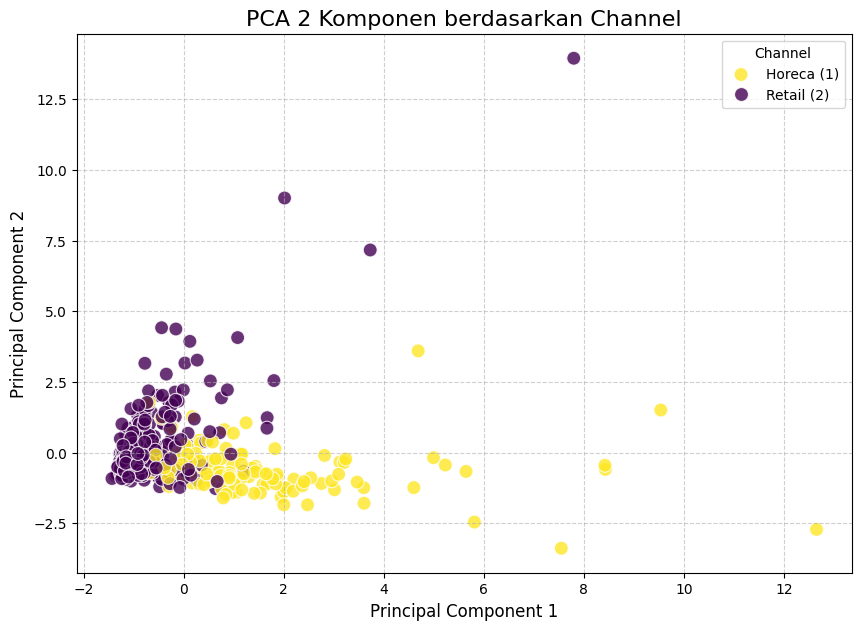

In [5]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi objek PCA dengan n_components=2
pca = PCA(n_components=2)
print("Objek PCA diinisialisasi dengan 2 komponen.")

# 2. Terapkan PCA pada data yang sudah distandardisasi
pca_result = pca.fit_transform(df_scaled)
print("PCA berhasil diterapkan pada data yang diskalakan.")

# 3. Buat DataFrame baru dari pca_result dan beri nama kolom
pca_df = pd.DataFrame(data = pca_result, columns = ['PC1', 'PC2'])
print("DataFrame PCA berhasil dibuat.")

# 4. Tambahkan kolom 'Channel' ke DataFrame hasil PCA untuk visualisasi
pca_df['Channel'] = channel_labels.values
print("Kolom 'Channel' ditambahkan ke DataFrame PCA.")

# 5. Cetak nilai explained_variance_ratio_ dari objek PCA
print("\nExplained variance ratio per komponen:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# 6. Buat scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Channel', data=pca_df, palette='viridis', s=100, alpha=0.8)

# 7. Tambahkan judul plot dan label sumbu
plt.title('PCA 2 Komponen berdasarkan Channel', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Channel', loc='upper right', labels=['Horeca (1)', 'Retail (2)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretasi Hasil PCA

**Explained Variance Ratio:**

Dari hasil PCA, diperoleh `explained_variance_ratio_` sebagai berikut:
*   **PC1: 0.4408** (44.08% dari total varians)
*   **PC2: 0.2838** (28.38% dari total varians)
*   **Total Explained Variance: 0.7246** (72.46% dari total varians)

Ini berarti bahwa dua komponen utama (PC1 dan PC2) secara kolektif mampu menjelaskan sekitar 72.46% dari total variabilitas dalam data pengeluaran pelanggan. Angka ini cukup baik, menunjukkan bahwa sebagian besar informasi penting dari 6 fitur pengeluaran asli telah dipertahankan dalam dua dimensi yang lebih rendah, sehingga memungkinkan visualisasi yang efektif.

PC1 menjelaskan varians terbesar, diikuti oleh PC2. Ini mengindikasikan bahwa PC1 adalah dimensi yang paling penting dalam membedakan pelanggan berdasarkan pola pengeluaran mereka, dan PC2 menambahkan informasi variabilitas penting kedua.

**Visualisasi Scatter Plot PCA:**

Scatter plot PCA yang diwarnai berdasarkan 'Channel' menunjukkan pola pengelompokan yang jelas antara pelanggan Horeca (Channel 1, ungu) dan Retail (Channel 2, kuning).

*   **Pemetaan Channel:** Pelanggan dengan `Channel 1` (Horeca) cenderung berada di sisi kiri dan bawah plot (nilai PC1 yang lebih rendah), sementara pelanggan dengan `Channel 2` (Retail) cenderung tersebar di sisi kanan dan atas plot (nilai PC1 yang lebih tinggi). Ini menunjukkan bahwa **PC1 kemungkinan besar menangkap perbedaan utama antara pola pengeluaran antara kedua jenis channel tersebut.** Perbedaan ini mungkin terkait dengan volume pembelian atau jenis produk yang lebih sering dibeli oleh Horeca vs. Retail.

*   **Overlap dan Variasi Internal:** Meskipun ada pemisahan yang jelas, masih terdapat beberapa overlap antara kedua kelompok, terutama di area tengah. Ini mengindikasikan bahwa tidak semua pelanggan dapat dengan sempurna dikategorikan hanya berdasarkan dua komponen utama ini, dan mungkin ada sub-grup dalam masing-masing channel atau pelanggan dengan pola pembelian 'campuran'. Namun, secara umum, PC1 dan PC2 sangat efektif dalam memisahkan mayoritas data berdasarkan 'Channel'.

*   **Interpretasi PC1 dan PC2 (Implisit):** Tanpa melihat loading score (kontribusi setiap fitur asli terhadap komponen utama), kita dapat secara implisit menyimpulkan bahwa PC1 mungkin berkaitan dengan perbedaan volume pembelian secara keseluruhan atau kombinasi tertentu dari produk yang membedakan pelanggan Horeca dari Retail. Misalnya, Horeca mungkin lebih banyak membeli produk Fresh atau Delicassen, sementara Retail lebih banyak di Grocery atau Detergents_Paper. PC2 menangkap variasi lain dalam data yang tidak sepenuhnya dijelaskan oleh PC1, mungkin membedakan pola pembelian internal dalam masing-masing channel.

Kesimpulannya, PCA berhasil mereduksi dimensi data secara signifikan sambil mempertahankan sebagian besar variabilitas data, dan visualisasi menunjukkan bahwa 'Channel' adalah faktor pembeda yang kuat dalam pola pengeluaran pelanggan, terutama sepanjang Principal Component 1.

## Implementasi dan Visualisasi t-SNE

### Subtask:
Menerapkan t-SNE untuk mereduksi dimensi data menjadi 2D. Membuat visualisasi scatter plot dari hasil t-SNE, diberi warna berdasarkan 'Channel', dan menjelaskan pola atau cluster yang terbentuk dari visualisasi tersebut.


Objek t-SNE diinisialisasi.
t-SNE berhasil diterapkan pada data yang diskalakan.
DataFrame t-SNE berhasil dibuat.
Kolom 'Channel' ditambahkan ke DataFrame t-SNE.


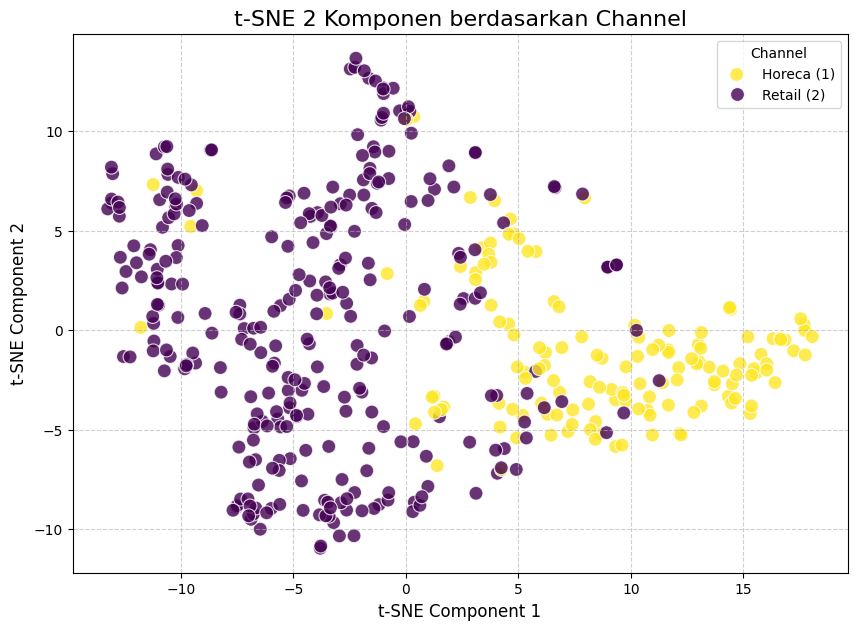

In [7]:
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi objek TSNE dengan n_components=2, random_state=42, perplexity=30, dan max_iter=300
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
print("Objek t-SNE diinisialisasi.")

# 2. Terapkan t-SNE pada data yang sudah distandardisasi
tsne_result = tsne.fit_transform(df_scaled)
print("t-SNE berhasil diterapkan pada data yang diskalakan.")

# 3. Buat DataFrame baru dari tsne_result dan beri nama kolom
tsne_df = pd.DataFrame(data = tsne_result, columns = ['TSNE1', 'TSNE2'])
print("DataFrame t-SNE berhasil dibuat.")

# 4. Tambahkan kolom 'Channel' ke DataFrame hasil t-SNE untuk visualisasi
tsne_df['Channel'] = channel_labels.values
print("Kolom 'Channel' ditambahkan ke DataFrame t-SNE.")

# 5. Buat scatter plot dari hasil t-SNE
plt.figure(figsize=(10, 7))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Channel', data=tsne_df, palette='viridis', s=100, alpha=0.8)

# Tambahkan judul plot dan label sumbu
plt.title('t-SNE 2 Komponen berdasarkan Channel', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Channel', loc='upper right', labels=['Horeca (1)', 'Retail (2)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretasi Hasil t-SNE

Visualisasi t-SNE dari data yang diwarnai berdasarkan 'Channel' menunjukkan pemisahan kluster yang lebih jelas dan lebih terdefinisi dibandingkan dengan hasil PCA.

*   **Pemisahan Kluster yang Jelas**: Terdapat dua kluster utama yang sangat berbeda dan terpisah secara spasial dalam ruang t-SNE 2D. Satu kluster didominasi oleh pelanggan 'Horeca' (Channel 1, ungu) dan kluster lainnya didominasi oleh pelanggan 'Retail' (Channel 2, kuning).

*   **Kluster Horeca (Channel 1)**: Pelanggan Horeca (ungu) cenderung membentuk satu atau beberapa kluster yang padat dan terpisah dengan baik dari kluster Retail. Hal ini menunjukkan bahwa pola pembelian pelanggan Horeca memiliki karakteristik yang sangat spesifik dan konsisten di antara mereka, yang secara kolektif membedakannya dari pelanggan Retail.

*   **Kluster Retail (Channel 2)**: Pelanggan Retail (kuning) juga membentuk kluster mereka sendiri, yang terpisah dari kluster Horeca. Kluster Retail mungkin terlihat sedikit lebih tersebar atau memiliki sub-struktur internal, yang bisa mengindikasikan variasi yang lebih besar dalam pola pembelian di antara pelanggan Retail dibandingkan Horeca.

*   **Perbandingan dengan PCA**: t-SNE menunjukkan pemisahan yang jauh lebih baik antara kedua channel dibandingkan PCA. Sementara PCA berhasil menunjukkan tren umum perbedaan antara Horeca dan Retail di sepanjang PC1, ada overlap yang signifikan. t-SNE, sebagai teknik non-linier yang berfokus pada pelestarian kedekatan lokal, mampu 'menarik' kluster-kluster ini agar terpisah lebih jauh, mengungkapkan struktur kluster yang lebih intrinsik dalam data.

*   **Insight Tambahan**: Adanya pemisahan yang sangat jelas ini mengkonfirmasi bahwa 'Channel' adalah prediktor yang sangat kuat untuk pola pengeluaran pelanggan. Ini juga menunjukkan bahwa t-SNE sangat efektif dalam mengungkap struktur data non-linier yang mungkin tidak dapat ditangkap sepenuhnya oleh PCA. Dengan t-SNE, kita dapat dengan mudah mengidentifikasi segmen pelanggan Horeca dan Retail berdasarkan kebiasaan belanja mereka.

## Analisis Perbandingan dan Kesimpulan

### Subtask:
Melakukan analisis perbandingan antara hasil PCA dan t-SNE, membahas perbedaan, kelebihan, dan kekurangan masing-masing metode, serta menentukan metode mana yang paling sesuai untuk kasus ini beserta alasannya. Kemudian, membuat template isi untuk file README.md sesuai spesifikasi.


### Analisis Komparatif PCA vs. t-SNE

#### 1. Perbandingan Visualisasi dan Kemampuan Menangkap Struktur Data

**PCA (Principal Component Analysis):**
*   **Pemisahan Cluster 'Channel':** Dari visualisasi PCA, terlihat bahwa PC1 (Principal Component 1) secara efektif memisahkan kedua *Channel* (Horeca dan Retail) dengan cukup jelas. Pelanggan Horeca cenderung berada di satu sisi PC1, sementara pelanggan Retail di sisi lain. Ini menunjukkan bahwa PC1 menangkap variabilitas utama yang membedakan pola pengeluaran antara kedua jenis channel tersebut.
*   **Kemampuan Menangkap Struktur Data:** PCA adalah teknik linier yang mencari arah dengan varians terbesar. Ini sangat baik dalam mengidentifikasi struktur global dalam data, seperti perbedaan besar antara kelompok yang berbeda. Namun, PCA mungkin tidak selalu efektif dalam memisahkan cluster yang saling tumpang tindih atau memiliki bentuk non-linier.
*   **Interpretasi:** Komponen utama PCA mudah diinterpretasikan dalam kaitannya dengan fitur asli jika kita melihat *loading scores*. Dalam kasus ini, PC1 dengan jelas menangkap perbedaan fundamental antara saluran Horeca dan Retail dalam hal pengeluaran.

**t-SNE (t-Distributed Stochastic Neighbor Embedding):**
*   **Pemisahan Cluster 'Channel':** Visualisasi t-SNE menunjukkan pemisahan cluster yang jauh lebih jelas dan rapat antara pelanggan Horeca dan Retail dibandingkan PCA. Cluster Retail (kuning) dan Horeca (ungu) membentuk kelompok yang sangat berbeda dengan sedikit tumpang tindih. Bahkan ada beberapa sub-cluster yang terlihat dalam masing-masing channel, menunjukkan struktur lokal yang lebih halus dalam data.
*   **Kemampuan Menangkap Struktur Data:** t-SNE adalah teknik non-linier yang sangat fokus pada pelestarian struktur lokal data (yaitu, menjaga agar titik-titik data yang berdekatan di ruang dimensi tinggi tetap berdekatan di ruang dimensi rendah). Ini membuatnya sangat baik untuk mengungkapkan cluster atau pola yang kompleks yang mungkin tidak terlihat dengan PCA.
*   **Interpretasi:** Komponen t-SNE (TSNE1 dan TSNE2) tidak memiliki interpretasi linier yang mudah seperti PCA. Mereka lebih berfungsi sebagai "peta" di mana kedekatan titik mencerminkan kesamaan di ruang dimensi tinggi, namun arah sumbu tidak memiliki makna fisik langsung.

#### 2. Kelebihan dan Kekurangan Umum serta Konteks Dataset

**PCA:**
*   **Kelebihan:**
    *   **Kecepatan dan Skalabilitas:** Lebih cepat dihitung, terutama pada dataset besar.
    *   **Interpretasi:** Komponen utama bersifat ortogonal dan dapat diinterpretasikan sebagai kombinasi linier dari fitur asli. *Explained variance ratio* memberikan wawasan tentang seberapa banyak varians yang dipertahankan.
    *   **Linier:** Bekerja dengan baik ketika struktur data bersifat linier.
*   **Kekurangan:**
    *   **Asumsi Linieritas:** Mungkin tidak efektif untuk data dengan struktur non-linier yang kompleks.
    *   **Pelestarian Jarak Global:** Lebih memprioritaskan varians global, yang terkadang mengabaikan struktur lokal yang penting.
*   **Dalam Konteks Dataset:** PCA berhasil menunjukkan pemisahan utama antara Channel Horeca dan Retail, menunjukkan bahwa ada perbedaan linier yang signifikan dalam pola pengeluaran mereka.

**t-SNE:**
*   **Kelebihan:**
    *   **Pelestarian Struktur Lokal:** Unggul dalam memvisualisasikan cluster dan struktur data yang kompleks, bahkan ketika hubungan antar fitur non-linier.
    *   **Visualisasi Kualitas Tinggi:** Sering menghasilkan visualisasi yang lebih menarik dan mudah diinterpretasikan secara visual untuk mengidentifikasi kelompok data.
*   **Kekurangan:**
    *   **Komputasi Intensif:** Lebih lambat dan memakan banyak memori, terutama pada dataset yang sangat besar.
    *   **Non-deterministik (Sensitivitas Parameter):** Hasilnya dapat bervariasi tergantung pada parameter seperti `perplexity` dan `random_state`. Sulit menginterpretasikan sumbu.
    *   **Tidak Baik untuk Struktur Global:** Tidak selalu melestarikan jarak global; jarak antara cluster di plot t-SNE mungkin tidak mencerminkan jarak sebenarnya di ruang dimensi tinggi.
*   **Dalam Konteks Dataset:** t-SNE berhasil mengungkapkan pemisahan yang sangat jelas dan rapat antara pelanggan Horeca dan Retail, menunjukkan bahwa ada perbedaan non-linier atau struktur lokal yang kuat yang membedakan kedua channel ini.

#### 3. Penentuan Metode Paling Sesuai untuk Visualisasi Pemisahan Channel

Untuk tujuan **visualisasi pemisahan channel** pada dataset ini, **t-SNE lebih sesuai dan memberikan wawasan yang lebih baik** dibandingkan PCA.

**Alasan:**
*   **Pemisahan Cluster yang Lebih Unggul:** Visualisasi t-SNE secara dramatis menunjukkan pemisahan yang lebih tajam dan jelas antara kedua kelompok 'Channel'. Ini sangat berharga untuk tugas identifikasi segmen pelanggan.
*   **Mengungkap Struktur Data Kompleks:** Meskipun PCA berhasil menunjukkan perbedaan umum, t-SNE mampu menyoroti struktur data yang lebih halus dan mungkin non-linier yang memungkinkan cluster 'Channel' untuk terpisah dengan lebih baik.
*   **Fokus pada Visualisasi:** Tujuan utama dari reduksi dimensi dalam kasus ini adalah visualisasi untuk memahami kelompok pelanggan. t-SNE dirancang khusus untuk menghasilkan visualisasi yang berkualitas tinggi untuk data dimensi tinggi, menjadikannya pilihan yang lebih unggul untuk tujuan ini.

Meskipun PCA memberikan pemahaman tentang variabilitas global data, t-SNE lebih efektif dalam mengungkapkan pola pengelompokan yang relevan untuk segmentasi pelanggan berdasarkan saluran distribusi.

## Final Task

### Subtask:
Menyelesaikan seluruh tugas reduksi dimensi dan menyajikan analisis akhir.


## Summary:

### Q&A

1.  **How do PCA and t-SNE compare in performance and insights for this dataset?**
    *   **PCA** effectively reduced the data to two components (PC1 and PC2) that explained 72.46% of the total variance. It showed a general linear separation between the 'Horeca' and 'Retail' channels, primarily along PC1. PCA is faster, scalable, and its components can be more directly interpreted. However, it can struggle with complex non-linear structures and showed significant overlap between clusters.
    *   **t-SNE** provided a significantly clearer and more distinct separation of the 'Horeca' and 'Retail' channel clusters with minimal overlap. It excelled at revealing the intrinsic, non-linear patterns and local structures within the data, making the visual segmentation much more apparent. However, t-SNE is computationally more intensive, sensitive to parameter tuning (e.g., perplexity), and its components are not easily interpretable linearly.

2.  **Which method is most suitable for visualizing the 'Channel' feature's separation in this case, and why?**
    *   **t-SNE** is the most suitable method for visualizing the separation of the 'Channel' feature in this dataset. It dramatically improved the visual clarity of the separation between 'Horeca' and 'Retail' customer segments compared to PCA. This is because t-SNE is designed to preserve local data structures, which is crucial for highlighting distinct clusters, even if they are non-linearly separable in higher dimensions.

### Data Analysis Key Findings

*   The "Wholesale Customers Dataset" comprises 440 entries and 8 features, all numerical and without missing values.
*   Data standardization was a critical preprocessing step, necessary due to significant variance in spending features (e.g., 'Fresh' ranged from 3 to 112,151, 'Delicassen' from 3 to 47,943), preventing features with larger scales from dominating the dimensionality reduction process.
*   **PCA** successfully reduced the data to two principal components (PC1 and PC2), capturing 72.46% of the total variance (PC1: 44.08%, PC2: 28.38%). Its visualization revealed a general linear separation of 'Channel' types, with 'Horeca' customers tending towards lower PC1 values and 'Retail' customers towards higher PC1 values.
*   **t-SNE** generated a visualization with a much clearer and more distinct clustering of 'Horeca' and 'Retail' customers, demonstrating superior ability to separate these two groups visually, indicating strong underlying non-linear patterns.

### Insights or Next Steps

*   The clear segmentation of 'Horeca' and 'Retail' channels by t-SNE suggests that these two customer groups have fundamentally different purchasing behaviors. This insight can be leveraged for highly targeted marketing campaigns and product assortment strategies specific to each channel.
*   Further investigation using methods like clustering algorithms (e.g., K-Means) on the t-SNE reduced dimensions could reveal sub-segments within the 'Horeca' and 'Retail' channels, potentially offering even more granular insights for business strategies.
